PCA FROM SCRATCH

In [3]:
import numpy as np

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.eigenvalues = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered, rowvar=False)

        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        self.components = eigenvectors[:, :self.n_components].T
        self.eigenvalues = eigenvalues[:self.n_components]
        total_var = np.sum(eigenvalues)
        self.explained_variance_ratio_ = self.eigenvalues / total_var

        return self

    def transform(self, X):
        X_centered = X - self.mean
        return X_centered @ self.components.T

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [4]:
np.random.seed(42)
n_samples = 500

t = np.random.uniform(0, 2 * np.pi, n_samples)
x1 = 3 * np.cos(t) + np.random.normal(0, 0.2, n_samples)
x2 = 3 * np.sin(t) + np.random.normal(0, 0.2, n_samples)
x3 = 0.5 * x1 + 0.3 * x2 + np.random.normal(0, 0.1, n_samples)

X_synthetic = np.column_stack([x1, x2, x3])

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_synthetic)

print(f"Original shape: {X_synthetic.shape}")
print(f"Reduced shape:  {X_reduced.shape}")
print(f"Explained variance ratios: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {sum(pca.explained_variance_ratio_):.4f}")

Original shape: (500, 3)
Reduced shape:  (500, 2)
Explained variance ratios: [0.59004014 0.40926775]
Total variance captured: 0.9993


Mnist DIGITS in 2D

In [5]:
from sklearn.datasets import fetch_openml

mnist=fetch_openml("mnist_784",version=1,as_frame=False,parser="auto")
X_mnist=mnist.data[:5000].astype(float)
y_mnist=mnist.target[:5000].astype(int)

pca_mnist=PCA(n_components=50)
X_pca50=pca_mnist.fit_transform(X_mnist)
print(f"50 components capture {sum(pca_mnist.explained_variance_ratio_):.2%} of variance")

pca_2d = PCA(n_components=2)
X_pca2d = pca_2d.fit_transform(X_mnist)
print(f"2 components capture {sum(pca_2d.explained_variance_ratio_):.2%} of variance")


50 components capture 82.91% of variance
2 components capture 17.27% of variance


Compare with sklearn

In [9]:
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import TSNE

sklearn_pca = SklearnPCA(n_components=2)
X_sklearn_pca = sklearn_pca.fit_transform(X_mnist)

print(f"\nOur PCA explained variance:     {pca_2d.explained_variance_ratio_}")
print(f"Sklearn PCA explained variance: {sklearn_pca.explained_variance_ratio_}")

diff = np.abs(np.abs(X_pca2d) - np.abs(X_sklearn_pca))
print(f"Max absolute difference: {diff.max():.10f}")


Our PCA explained variance:     [0.09867566 0.07404546]
Sklearn PCA explained variance: [0.09867566 0.07404546]
Max absolute difference: 0.0139264139


In [10]:

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_mnist)
print(f"\nt-SNE output shape: {X_tsne.shape}")


t-SNE output shape: (5000, 2)


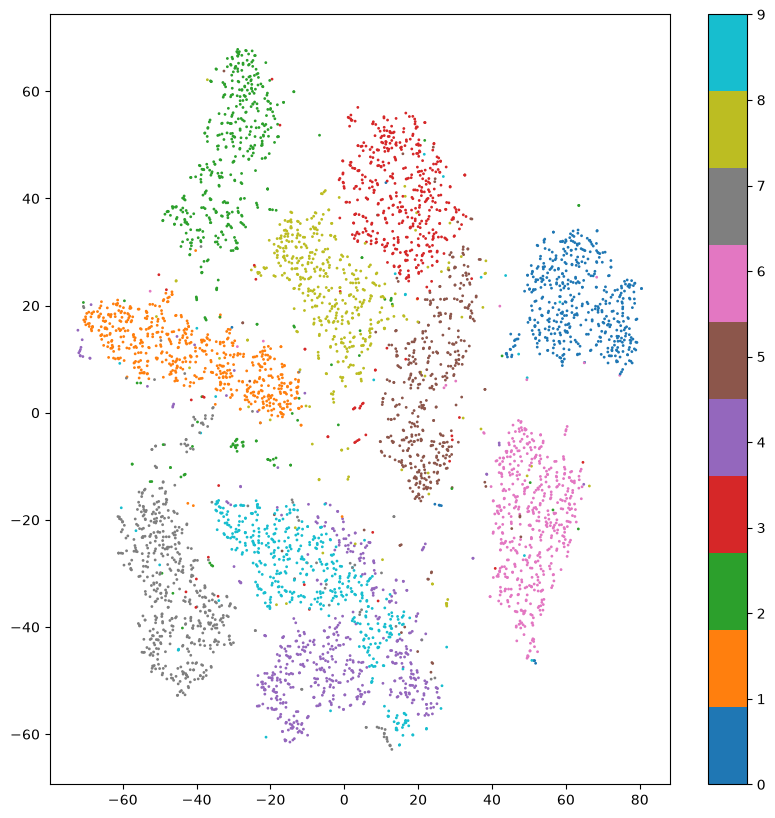

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_mnist, cmap='tab10', s=1)
plt.colorbar()
plt.show()

 UMAP comparison

In [13]:
try:
    from umap import UMAP

    reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_mnist)
    print(f"UMAP output shape: {X_umap.shape}")
except ImportError:
    print("Install umap-learn: pip install umap-learn")

/home/saransh/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (5000, 2)


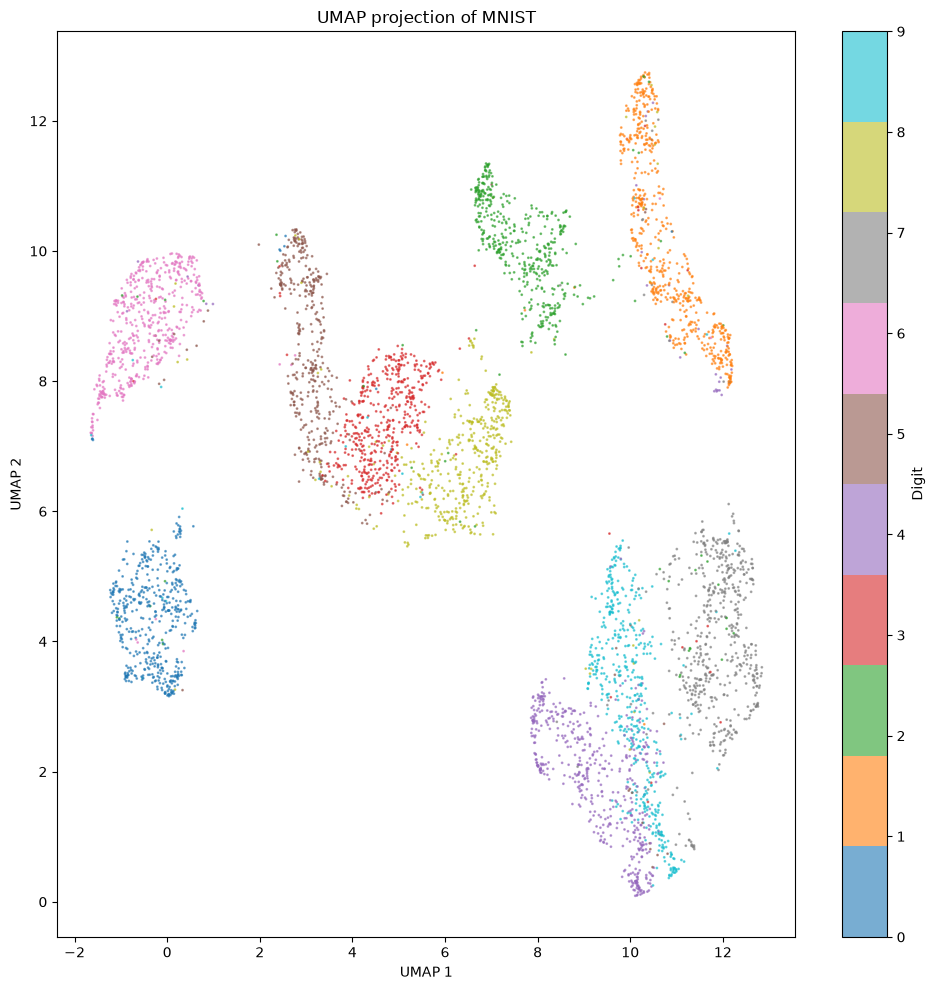

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))
scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y_mnist,          # labels 0-9
    cmap='tab10',
    s=1,                # point size — keep small for 60k points
    alpha=0.6
)
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.title('UMAP projection of MNIST')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

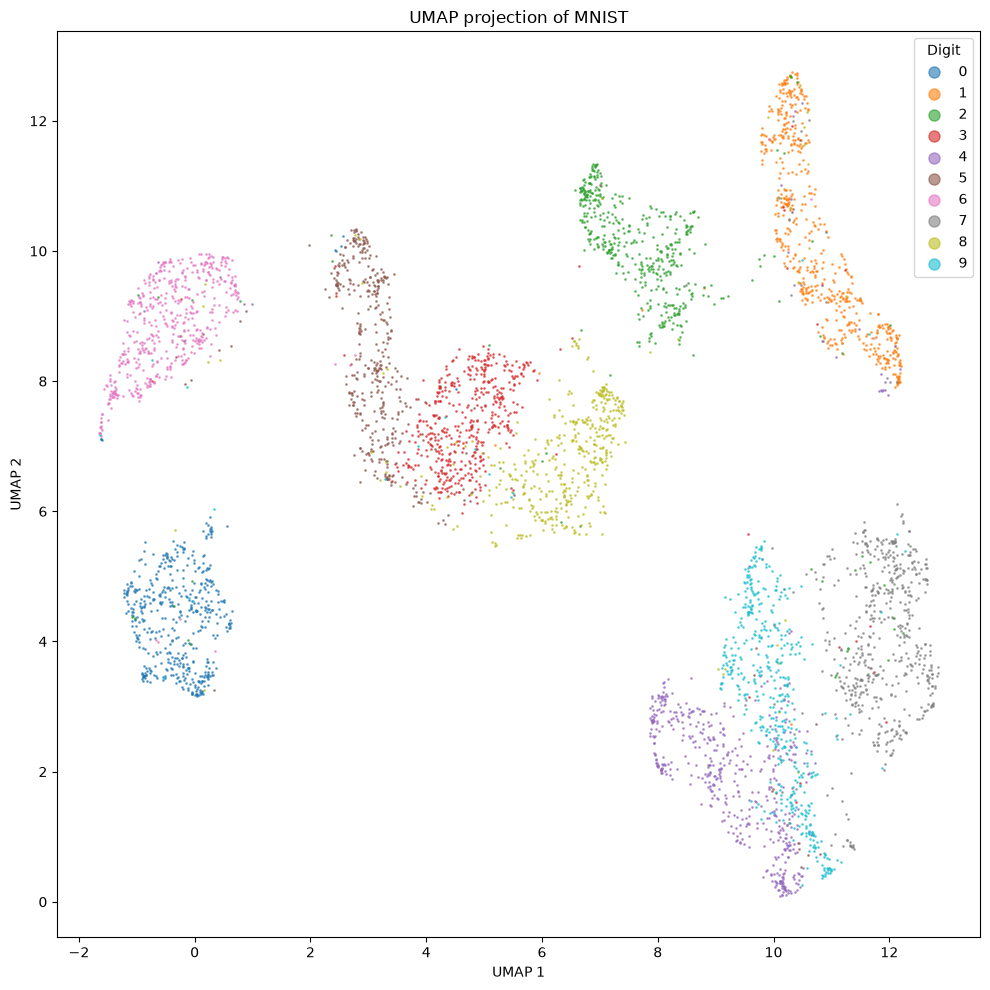

In [15]:
plt.figure(figsize=(10, 10))

for digit in range(10):
    mask = (y_mnist == digit)
    plt.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        s=1,
        alpha=0.6,
        label=str(digit)
    )

plt.legend(markerscale=8, title='Digit', loc='best')
plt.title('UMAP projection of MNIST')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()